# Spatio Temporal Analysis of Martket Prices

## 1. Intorodcution

This chapter focuses on **spatiotemporal data analysis** using **network science**, particularly on how prices and sales evolve across both **space (locations)** and **time (quarters or months)**. The authors use two datasets:

1. **Burkina Faso Millet Market Prices (2015–2022):**
   * Tracks millet prices across multiple markets in Burkina Faso.
   * Key events: COVID-19 and Ukraine conflict, which caused food supply disruptions and price fluctuations.
   * Spatial relationships between markets are modeled using a **weight matrix** (based on shared borders).
   * Each time slice is one year, with three-quarter overlap.
   <br><br>

2. **Simulated Store Sales Dataset (During/After COVID-19):**
   * Tracks sales across 4 stores in a mid-sized city.
   * Sales trends are influenced by population migration, remote work, and return-to-office policies.
   * Spatial relationships between stores are assumed fully connected (all stores influence each other).

The chapter demonstrates:

* **Time slicing** the data into overlapping windows.
* **Building networks per slice** using **Correlation thresholding** to identify strong relationships and **Local Moran's I** to account for spatial autocorrelation.
* **Calculating network metrics:** **PageRank centrality** (to measure influence) and **Forman-Ricci curvature** (to measure network robustness or fragility).

Finally, the chapter shows how to:

* Plot changes in **PageRank** and **Forman-Ricci curvature** across time.
* Identify periods of high or low volatility.
* Use this information to guide interventions (e.g., managing store inventory, understanding price volatility).


## 2. Import data and packages

In [2]:
#import packages
import igraph as ig
from igraph import Graph
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

### Import prices

In [88]:
#import Burkina Faso market millet prices
File="/home/sako/Data science lessons/Graph Theory/Book Course (Python with Network science)/data/BF_Millet.csv"
df_grain_price=pd.read_csv(File,encoding='latin1')

In [89]:
top_summary = df_grain_price.describe().T.sort_values('mean').head(5)
top_summary

,count,mean,std,min,25%,50%,75%,max
BANWA,29.0,159.528736,36.796795,108.000000,137.666667,153.666667,176.666667,282.666667
TUY,29.0,165.885057,38.073162,123.000000,138.000000,151.333333,196.333333,289.666667
NAYALA,29.0,169.496552,31.102459,126.666667,152.666667,163.333333,181.200000,288.166667
KOMPIENGA,29.0,169.643678,35.247670,116.000000,147.000000,161.666667,190.000000,247.000000
KOMANDJARI,29.0,177.666667,43.085878,122.333333,157.000000,166.333333,200.833333,310.166667


Text(0, 0.5, 'Prices')

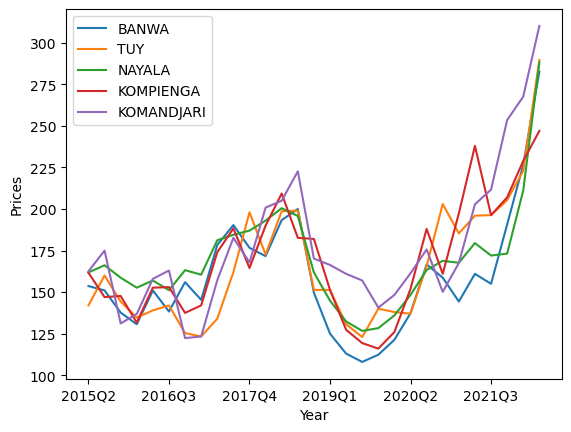

In [90]:
df_grain_price[['Year']+ top_summary.index.tolist()].plot(x='Year')
plt.ylabel("Prices")

### Import weights for geographic connections

In [91]:
#import weight matrix of Burkina Faso markets
File="/home/sako/Data science lessons/Graph Theory/Book Course (Python with Network science)/data/weights_bk.csv"
weights_grain=pd.read_csv(File,encoding='latin1')

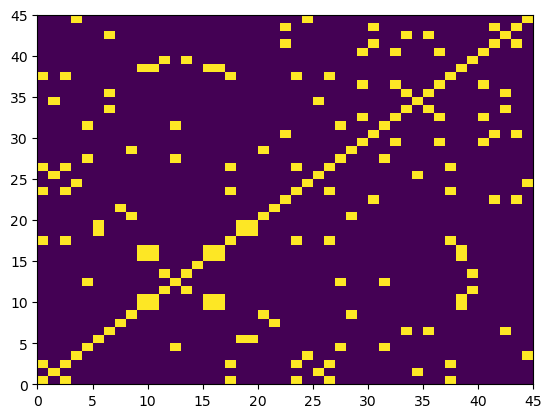

In [92]:
plt.pcolormesh(weights_grain.drop("Year",axis=1).to_numpy())

### Import Paper Store Data 

In [109]:
#import Store Sales dataset
File="/home/sako/Data science lessons/Graph Theory/Book Course (Python with Network science)/data/Store_Sales.csv"

df_paper=pd.read_csv(File,encoding='latin1')

In [121]:
df_plot = df_paper.iloc[:,1:]
df_plot.index = pd.to_datetime(df_paper.Month,format='%b-%y')

<Axes: title={'center': 'Sales per month'}, xlabel='Month'>

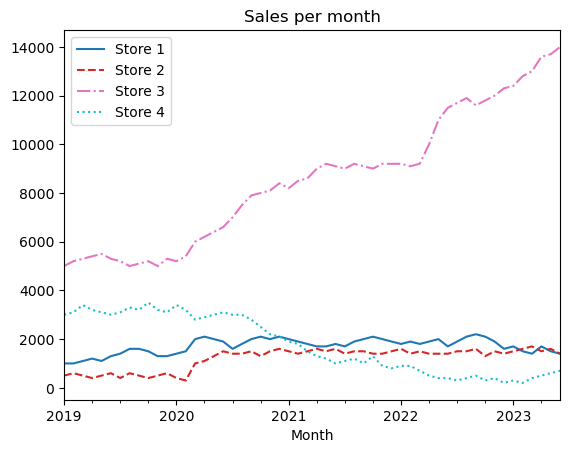

In [126]:
df_plot.plot(    style=['-', '--', '-.', ':'], # Different line styles
                colormap='tab10',             # Nice, distinct color palette
                title='Sales per month')

## 3. Initiate Analsysis for Grain prices

### Estimate centrality matrices for windows of grain prices

In [93]:
#score in yearly sets with 3 quarter overlap
vcurv_t=[] 
vcurv_ave=[]
eig_t=[]
eig_ave=[]
nets=[]

# clean weights  
weights_total = weights_grain.iloc[:,1:46]

# generate a self it once to use later
self_loop = [(i,i) for i in range(0,46)]


for Year in range(4,29):
    
    # estimate timeseries correlations with a window of 3 quarters
    data=df_grain_price.iloc[(Year-4):(Year),1:46]
    cor=np.corrcoef(data.transpose())

    # create a correlations for nodes of value base 0.9
    cor[cor>=0.9]=1
    cor[cor<0.9]=0

    # multiply with geographical weigths to generate final graph adjacency matrix
    cor_weighted = np.multiply(cor,weights_total)
    bf_market_w = Graph.Adjacency(cor_weighted)
    edge_list = bf_market_w.get_edgelist()

    # self loops will be removed     
    to_remove=[]
    for i in edge_list:
        for j in self_loop:
            if i==j:
                to_remove.append(i)
    bf_market_w.delete_edges(to_remove)


    # store the graphs 
    nets.append(bf_market_w)
    
    # calculate centrality metrics 
    d=Graph.degree(bf_market_w)
    e=Graph.pagerank(bf_market_w)
    eig_t.append(e)
    eig_ave.append(np.mean(e))
    ecurvw=[]

    # Forman-Ricci curvature
    for edge in bf_market_w.es:
        s=edge.source
        t=edge.target
        ecurvw.append(2-d[s]-d[t])
    vcurvw=[]
    for vertex in bf_market_w.vs:
        inc=Graph.incident(bf_market_w,vertex)
        inc_curv=[]
        for i in inc:
            inc_curv.append(ecurvw[i])
        vcurvw.append(sum(inc_curv))
        
    vcurv_t.append(vcurvw)
    vcurv_ave.append(np.mean(vcurv_t))

### Visualize results of centrality metrics of grain prices

In [94]:
df_metrics = pd.DataFrame()
df_metrics['pagerank'] = np.round(eig_ave,decimals=3)
df_metrics['FR'] = vcurv_ave
df_metrics.index=range(1,df_metrics.shape[0]+1)

array([[<Axes: title={'center': 'pagerank'}>,
        <Axes: title={'center': 'FR'}>]], dtype=object)

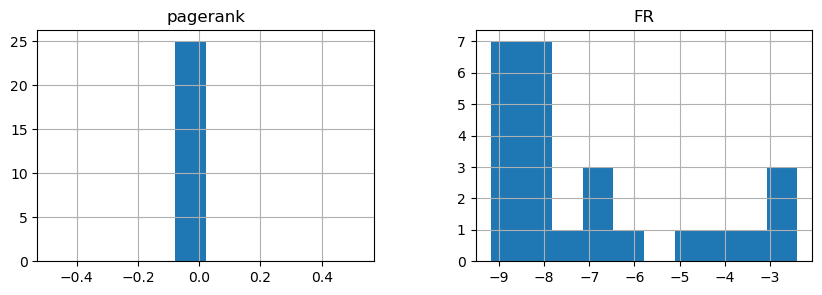

In [95]:
#plot metric averages across time slices
df_metrics.hist(layout=(1,2),figsize=(10,3))

<Axes: >

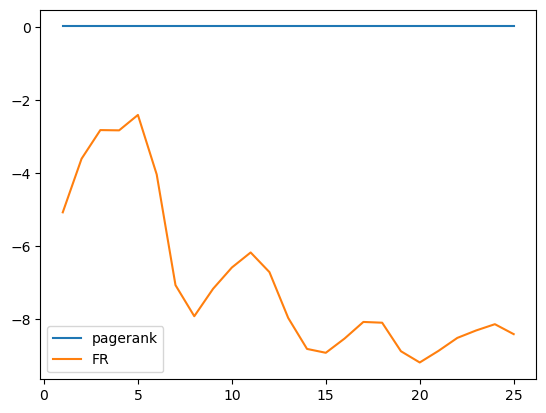

In [96]:
#plot metric averages across time slices
df_metrics.plot(layout=(1,2))

### Visualize the graphs of grain prices

#### Window 4 -> FR = -2.4

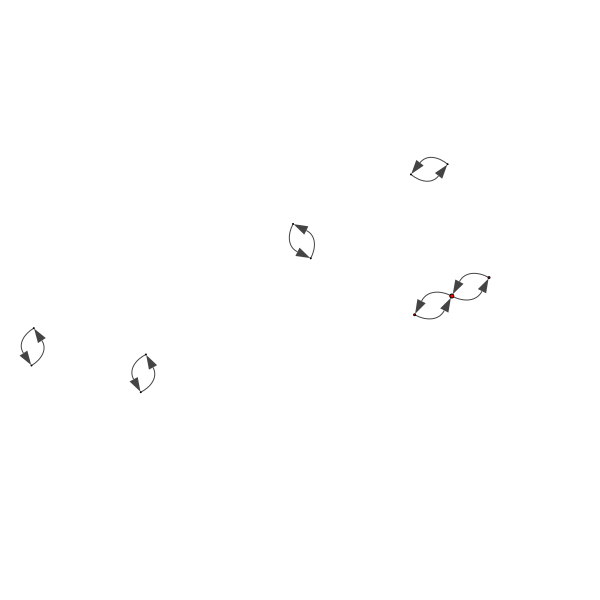

In [97]:
#examine different time points with Forman-Ricci curvature plots, fourth slice
ig.plot(nets[4],
        vertex_size=np.array(vcurv_t[4])*-0.5)

#### Window 9 -> FR = -6.577

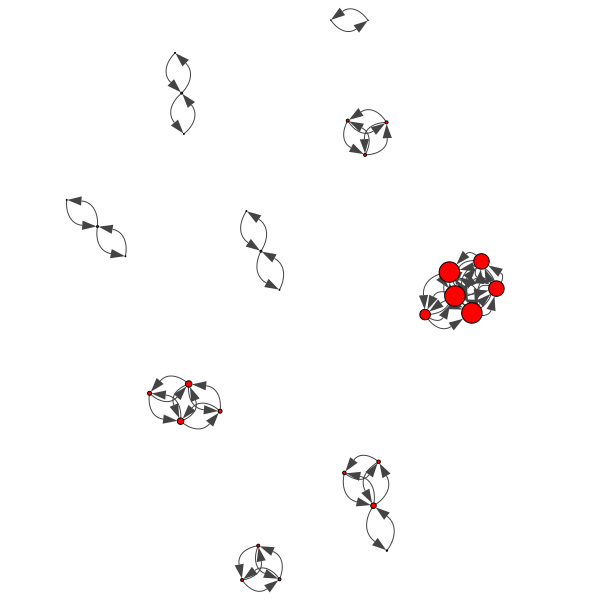

In [98]:
#examine different time points with Forman-Ricci curvature plots, 19th slice
ig.plot(nets[19],
        vertex_size=np.array(vcurv_t[19])*-0.25)

## 4.Initiate Analsysis for Store paper sales

In [130]:
#score in yearly sets with 3 quarter overlap
vcurv_t=[]
vcurv_ave=[]
eig_t=[]
eig_ave=[]
nets=[]

# generate a self it once to use later
self_loop = [(i,i) for i in range(0,46)]

for Month in range(2,54):

    # Window size will be for range of 2 months  
    data= df_paper.iloc[(Month-2):(Month),1:6]
    
    # calculate correlations
    cor=np.corrcoef(data.transpose())
    cor[cor>=0.9]=1
    cor[cor<0.9]=0

    # Create correlation 
    stores=Graph.Adjacency(cor)
    edge_list=stores.get_edgelist()
    
    # remove self loops
    to_remove=[]
    for i in edge_list:
        for j in self_loop:
            if i==j:
                to_remove.append(i)
    stores.delete_edges(to_remove)
    
    # Save node for later visualization
    nets.append(stores)

    # calculate metircs 
    d=Graph.degree(stores)
    e=Graph.pagerank(stores)
    eig_t.append(e)
    eig_ave.append(np.mean(e))

    # Calcualte Forman-Ricci curvature
    ecurvw=[]
    for edge in stores.es:
        s=edge.source
        t=edge.target
        ecurvw.append(2-d[s]-d[t])
    vcurvw=[]
    for vertex in stores.vs:
        inc=Graph.incident(stores,vertex)
        inc_curv=[]
        for i in inc:
            inc_curv.append(ecurvw[i])
        vcurvw.append(sum(inc_curv))
    vcurv_t.append(vcurvw)
    vcurv_ave.append(np.mean(vcurv_t))

/home/sako/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sako/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/sako/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sako/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/sako/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/sako/anaconda3/lib/python3.11/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/sako/anaconda3/lib/python3.11/site-packages/nu

In [131]:
df_metrics = pd.DataFrame()
df_metrics['pagerank'] = np.round(eig_ave,decimals=3)
df_metrics['FR'] = vcurv_ave
df_metrics.index=range(1,df_metrics.shape[0]+1)

array([[<Axes: title={'center': 'pagerank'}>,
        <Axes: title={'center': 'FR'}>]], dtype=object)

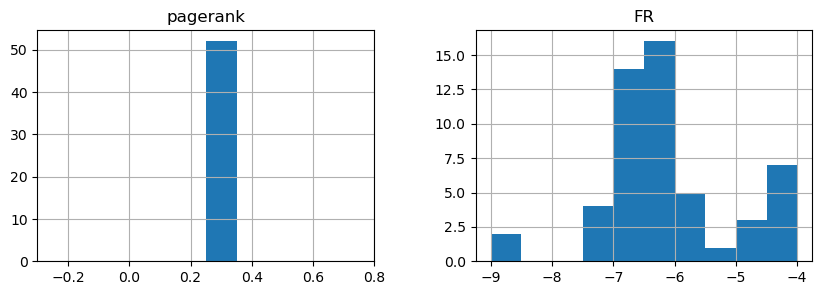

In [132]:
#plot metric averages across time slices
df_metrics.hist(layout=(1,2),figsize=(10,3))

<Axes: >

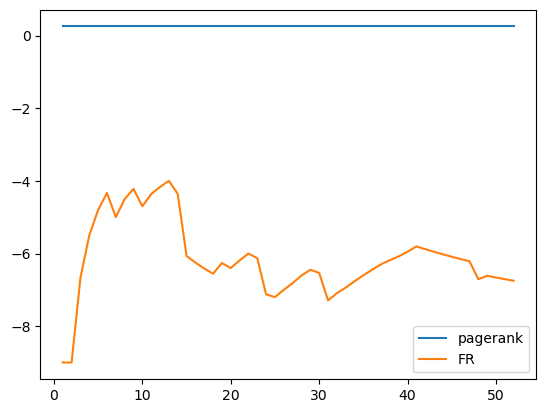

In [133]:
#plot metric averages across time slices
df_metrics.plot(layout=(1,2))

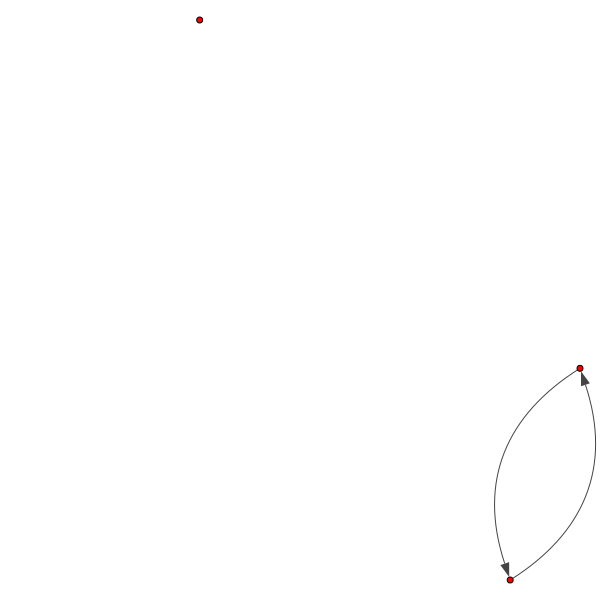

In [139]:
#examine different time points with Forman-Ricci curvature plots, tenth slice
ig.plot(nets[10],vertex_size=np.array(vcurv_t[13])*-0.5)

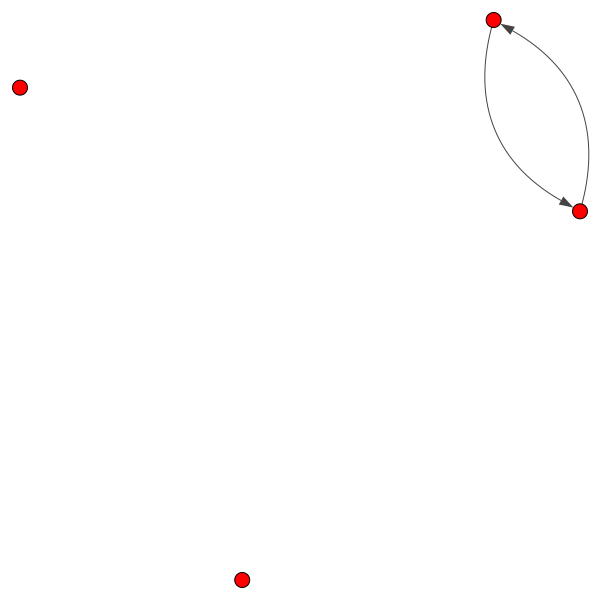

In [138]:
#examine different time points with Forman-Ricci curvature plots, tenth slice
ig.plot(nets[10],vertex_size=np.array(vcurv_t[30])*-0.5)

## 5. Conclusion

We conclude that the Forman-Ricci curvature metric shows very high values for when there is high connectivity and low values when the connectivity is weak. It is an efficient algorithm as it is iterative and parallelizable. 